# Table of Content

- [1. Introduction](#1-introduction)
  - [1.1 Problem Statement](#11-problem-statement)
  - [1.2 Dataset](#12-dataset)
- [2. Methodology](#2-methodology)
  - [2.1 Data Preprocessing](#21-data-preprocessing)
  - [2.2 Data Analysis](#22-data-analysis)
- [3. Modelling](#3-modelling)
- [4. Evaluation](#4-evaluation)
- [5. Conclusion and Future Work](#5-conclusion-and-future-work)

# 1. Introduction



## 1.1 Problem Statement

## 1.2 Dataset

In [1]:
# Import Libraries
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
# preprocessing and metrics
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_squared_log_error, make_scorer


In [2]:

# Create a df describing each variable
variables = [
    "instant", "dteday", "season", "yr", "mnth", "hr", "holiday",
    "weekday", "workingday", "weathersit", "temp", "atemp", "hum",
    "windspeed", "casual", "registered", "cnt"
]

descriptions = [
    "Record index",
    "Date of the observation",
    "Season (1: Spring, 2: Summer, 3: Fall, 4: Winter)",
    "Year (0: 2011, 1: 2012)",
    "Month (1 to 12)",
    "Hour (0 to 23) – not available in day.csv",
    "Indicator if the day is a holiday (1: holiday, 0: not)",
    "Day of the week (0: Sunday to 6: Saturday)",
    "Indicator if day is working day (1) or weekend/holiday (0)",
    "Weather situation (1: Clear/Few clouds, 2: Mist/Cloudy, 3: Light Snow/Rain, 4: Heavy Rain/Snow)",
    "Normalized temperature in Celsius (divided by 41)",
    "Normalized feeling temperature in Celsius (divided by 50)",
    "Normalized humidity (divided by 100)",
    "Normalized wind speed (divided by 67)",
    "Count of casual users (leisure)",
    "Count of registered users (subscribers)",
    "Total count of bike rentals (casual + registered)"
]

df_variables = pd.DataFrame({
    "Variable": variables,
    "Description": descriptions
})


df_variables.head(18)



,Variable,Description
0,instant,Record index
1,dteday,Date of the observation
2,season,"Season (1: Spring, 2: Summer, 3: Fall, 4: Winter)"
3,yr,"Year (0: 2011, 1: 2012)"
4,mnth,Month (1 to 12)
5,hr,Hour (0 to 23) – not available in day.csv
6,holiday,"Indicator if the day is a holiday (1: holiday,..."
7,weekday,Day of the week (0: Sunday to 6: Saturday)
8,workingday,Indicator if day is working day (1) or weekend...
9,weathersit,"Weather situation (1: Clear/Few clouds, 2: Mis..."


In [3]:
day_bike = pd.read_csv('day.csv')
day_bike.head(10)


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600
5,6,2011-01-06,1,0,1,0,4,1,1,0.204348,0.233209,0.518261,0.089565,88,1518,1606
6,7,2011-01-07,1,0,1,0,5,1,2,0.196522,0.208839,0.498696,0.168726,148,1362,1510
7,8,2011-01-08,1,0,1,0,6,0,2,0.165000,0.162254,0.535833,0.266804,68,891,959
8,9,2011-01-09,1,0,1,0,0,0,1,0.138333,0.116175,0.434167,0.361950,54,768,822
9,10,2011-01-10,1,0,1,0,1,1,1,0.150833,0.150888,0.482917,0.223267,41,1280,1321


In [4]:
day_bike.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [5]:
#Get basic idea of data using describe()
day_bike.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [6]:
def enhanced_data_overview(df, head_rows=5):
    """
    Displays an extended overview of the DataFrame:
    - Shape (rows, columns)
    - Memory usage
    - Missing values (count + percentage)
    - Duplicate rows
    - Data types
    - Number of unique values per column
    - Head (first rows)
    - Descriptive statistics for numeric features
    - Descriptive statistics for categorical features
    """
    # 1. Shape
    display(Markdown("## Shape"))
    print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")
    
    # 2. Memory Usage
    display(Markdown("## Memory Usage"))
    mem_usage = df.memory_usage(deep=True).sum() / (1024 ** 2)
    print(f"Total Memory Usage: {mem_usage:.2f} MB\n")
    
    # 3. Missing Values
    display(Markdown("## Missing Values"))
    missing = pd.DataFrame({
        'Missing Count': df.isnull().sum(),
        'Missing %': (df.isnull().mean() * 100).round(2)
    })
    display(missing)
    
    # 4. Duplicate Rows
    display(Markdown("## Duplicate Rows"))
    dup_count = df.duplicated().sum()
    print(f"Number of duplicate rows: {dup_count}\n")
    
    # 5. Data Types
    display(Markdown("## Data Types"))
    display(pd.DataFrame(df.dtypes, columns=['Dtype']))
    
    # 6. Unique Values Count
    display(Markdown("## Unique Values per Column"))
    unique_counts = pd.DataFrame({
        'Unique Count': df.nunique(),
        'Data Type': df.dtypes
    })
    display(unique_counts)

    # 7. Head (first rows)
    display(Markdown("## Head (First Rows)"))
    display(df.head(head_rows))

    # 8. Bottom (last rows)
    display(Markdown("## Bottom (Last Rows)"))
    display(df.tail(head_rows))

    #9. Descriptive Statistics
    display(Markdown("## Descriptive Statistics"))
    display(df.describe(include='all'))

# Call the function to display the overview
enhanced_data_overview(day_bike, head_rows=5)

## Shape

Rows: 731, Columns: 16



## Memory Usage

Total Memory Usage: 0.13 MB



## Missing Values

...

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


## Bottom (Last Rows)

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
726,727,2012-12-27,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114
727,728,2012-12-28,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095
728,729,2012-12-29,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341
729,730,2012-12-30,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796
730,731,2012-12-31,1,1,12,0,1,1,2,0.215833,0.223487,0.577500,0.154846,439,2290,2729


## Descriptive Statistics

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
unique,NaN,731,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,2011-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,366.000000,NaN,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,NaN,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,NaN,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,NaN,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,NaN,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000


# 2. Methodology

# 2.1 Data Preprocessing

In [7]:
def extract_features_categorical(df, cat_th = 13, num_th = 20):
    """
    Extracts categorical features from the DataFrame based on thresholds for unique values.
    
    Parameters:
    - df: DataFrame to extract features from
    - cat_th: Threshold for categorical features (default 13)
    - num_th: Threshold for numerical features (default 20)
    
    Returns:
    - cat_cols: List of categorical feature names
    - num_cols: List of numerical feature names
    """
    # 1. Identify 'true' categorical columns
    cat_cols = [col for col in df.columns if df[col].dtype == "O"]

    # 2. Identify numeric columns that should be treated as categorical
    #    because they have fewer than cat_th unique values
    num_but_cat = [
        col for col in df.columns
        if df[col].nunique() < cat_th and df[col].dtypes != "O"
    ]
    # 3. Identify 'categorical but high cardinality' columns
    cat_but_car = [
        col for col in df.columns
        if df[col].nunique() > cat_th and df[col].dtypes == "O"
    ]
    # 4. Combine object-type categorical columns and numeric-but-categorical columns,
    #    then exclude any high-cardinality columns
    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    # 5. Identify numeric columns (dtype != object), excluding those in num_but_cat
    num_cols = [col for col in df.columns if df[col].dtype != "O"]
    num_cols = [col for col in num_cols if col not in num_but_cat]

    # 6. Identify binary categorical columns (exactly two unique values)
    binary_cols = [col for col in cat_cols if df[col].nunique() == 2]

    # 7. Identify non-binary categorical columns
    only_cat_cols = list(set(cat_cols) - set(binary_cols))

    
    return cat_cols, num_cols

In [8]:
# Renaming columns for better readability 
day_bike.rename(columns={
    'yr': 'year',
    'mnth': 'month',
    'hr': 'hour',
    'temp': 'temperature',
    'atemp': 'feeling_temperature',
    'hum': 'humidity',
    'cnt': 'total_count',
    'dteday': 'date',

}, inplace=True)
# Display the first few rows of the modified DataFrame
day_bike.head()

,instant,date,season,year,month,holiday,weekday,workingday,weathersit,temperature,feeling_temperature,humidity,windspeed,casual,registered,total_count
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [9]:
categorical_variables, numerical_variables = extract_features_categorical(day_bike, cat_th=13, num_th=20)

# Display the categorical and numerical variables
print("Categorical Variables:")
print(categorical_variables)

print("\nNumerical Variables:")
print(numerical_variables)




Categorical Variables:
['season', 'year', 'month', 'holiday', 'weekday', 'workingday', 'weathersit']

Numerical Variables:
['instant', 'temperature', 'feeling_temperature', 'humidity', 'windspeed', 'casual', 'registered', 'total_count']


# 2.2 Data Analysis

## Descriptive Statistics for Numerical Features

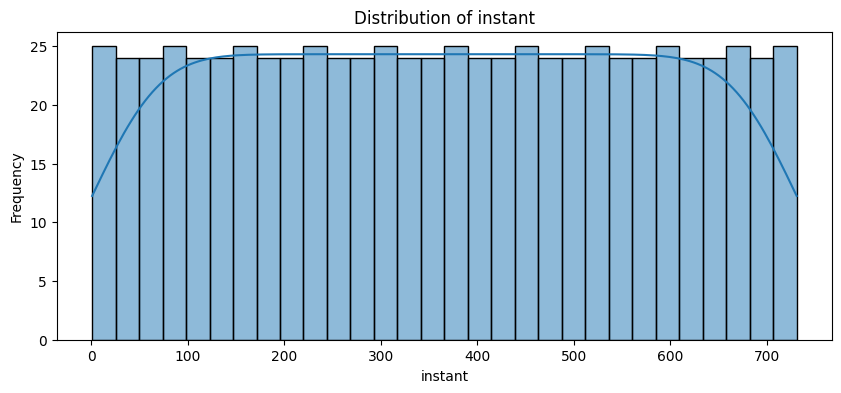

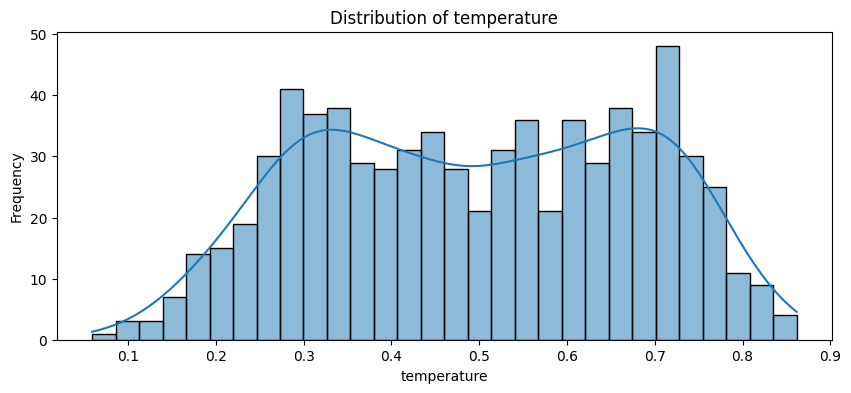

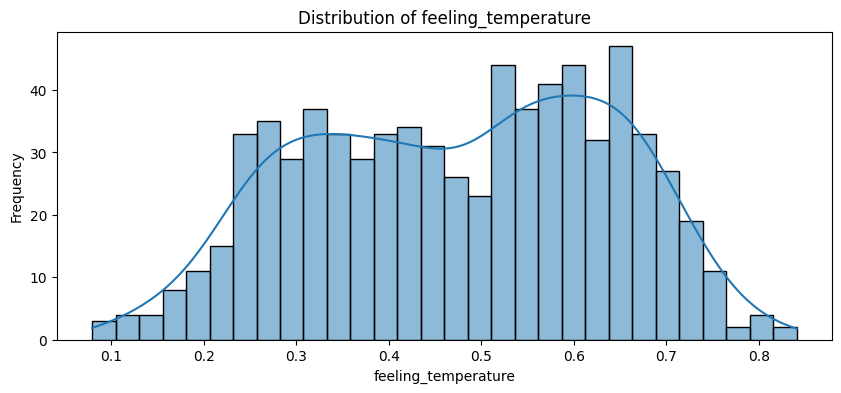

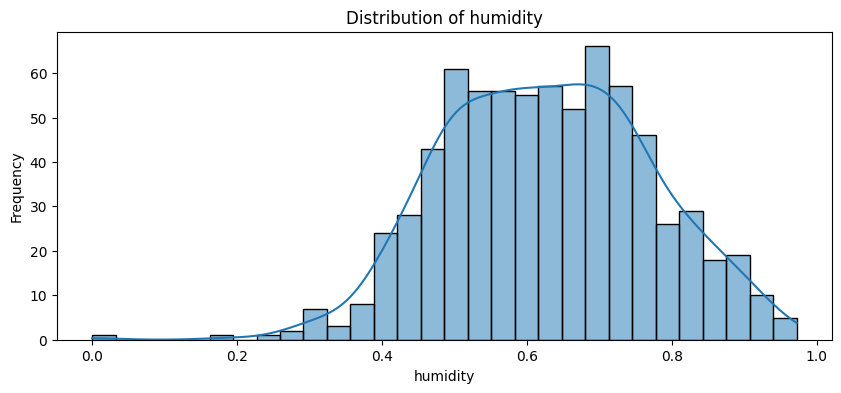

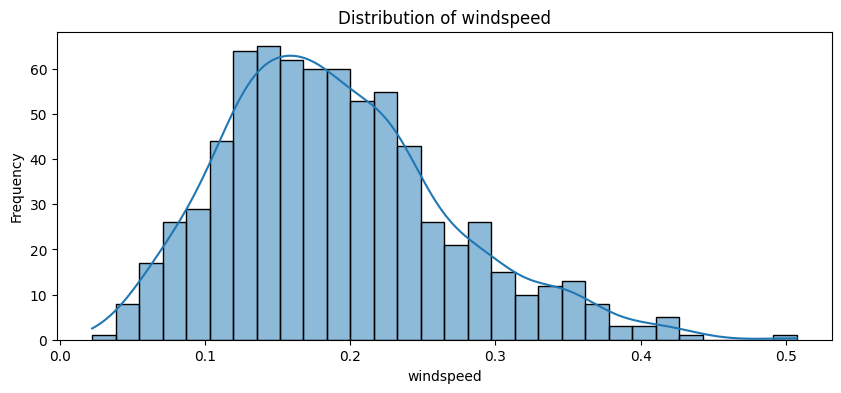

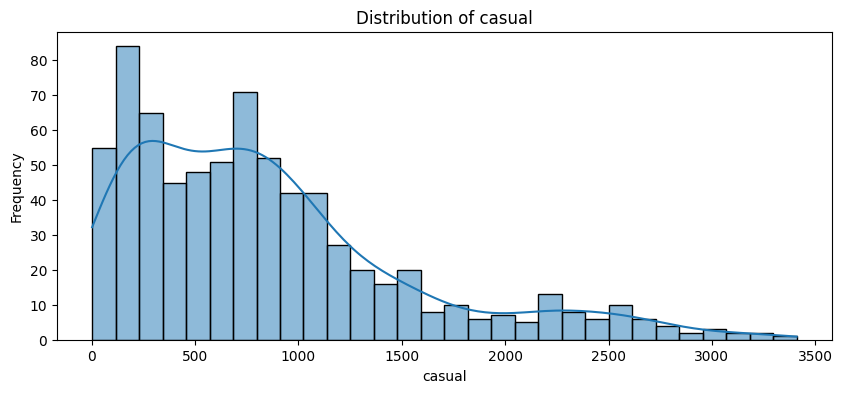

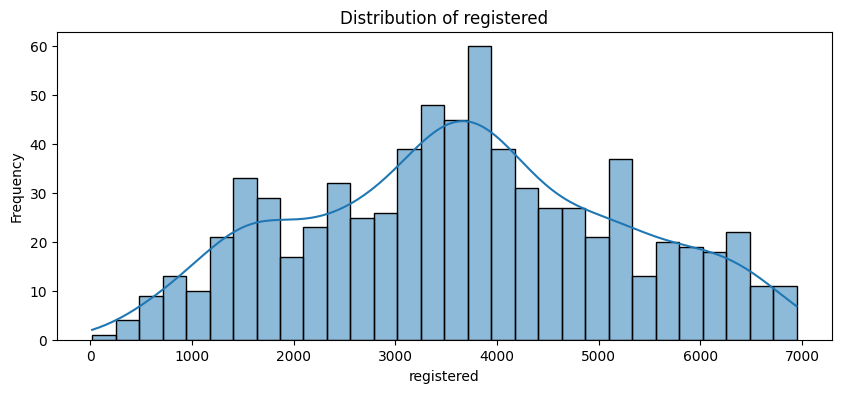

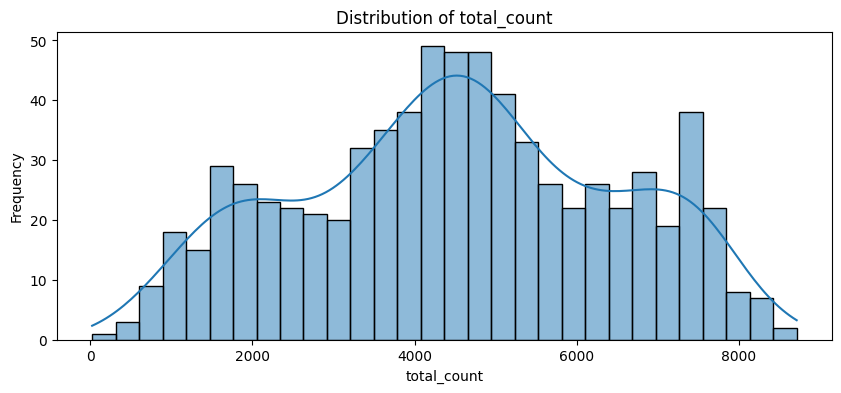

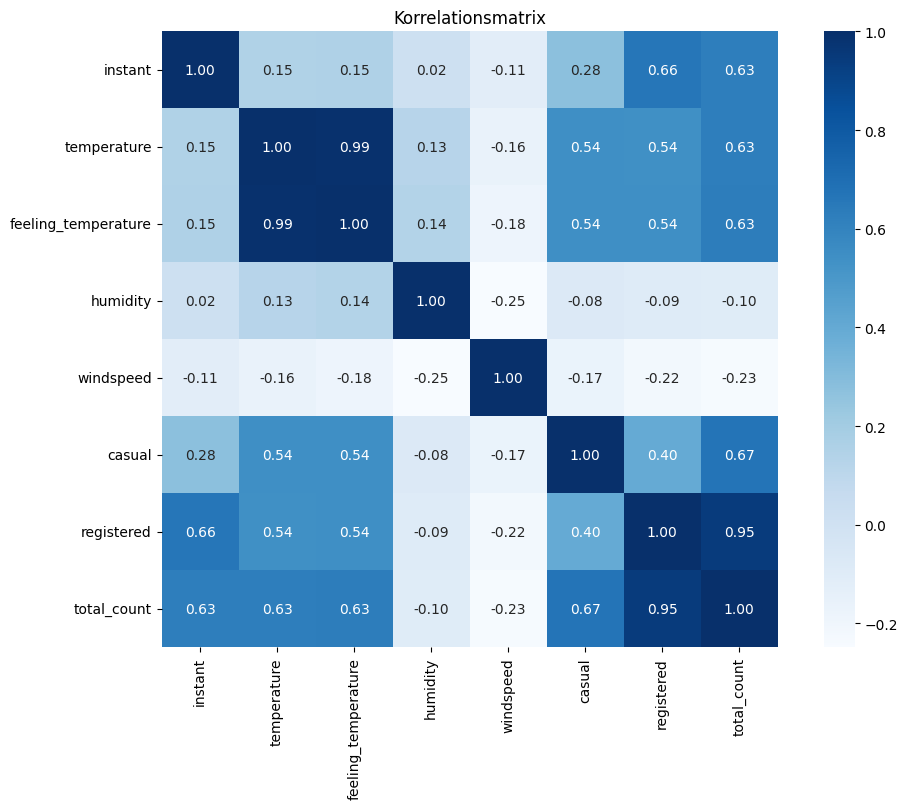

In [10]:
# TODO:
# 1. Alyse numerical variables
# 2. Visualize categorical variables
def analyze_numerical_features(df, numerical_features):
    """
    Analyzes numerical features in the DataFrame:
    - Displays descriptive statistics
    - Visualizes distributions and correlations
    """
    # Descriptive statistics
    display(Markdown("## Descriptive Statistics for Numerical Features"))
   

    # Visualize distributions of numerical features
    for feature in numerical_features:
        plt.figure(figsize=(10, 4))
        sns.histplot(df[feature], kde=True, bins=30)
        plt.title(f'Distribution of {feature}')
        plt.xlabel(feature)
        plt.ylabel('Frequency')
        plt.show()

# Analyze numerical features
analyze_numerical_features(day_bike, numerical_variables)

# Korrelationsmatrix (Heatmap) mit blauen Farben
def plot_correlation_matrix(df, numerical_features):    
    """
    Plots a correlation matrix heatmap for numerical features in the DataFrame.
    
    Parameters:
    - df: DataFrame containing the data
    - numerical_features: List of numerical feature names
    """
    plt.figure(figsize=(12, 8))
    corr_matrix = df[numerical_features].corr()
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='Blues', square=True)
    plt.title('Korrelationsmatrix')
    plt.show()

# Plot the correlation matrix
plot_correlation_matrix(day_bike, numerical_variables)

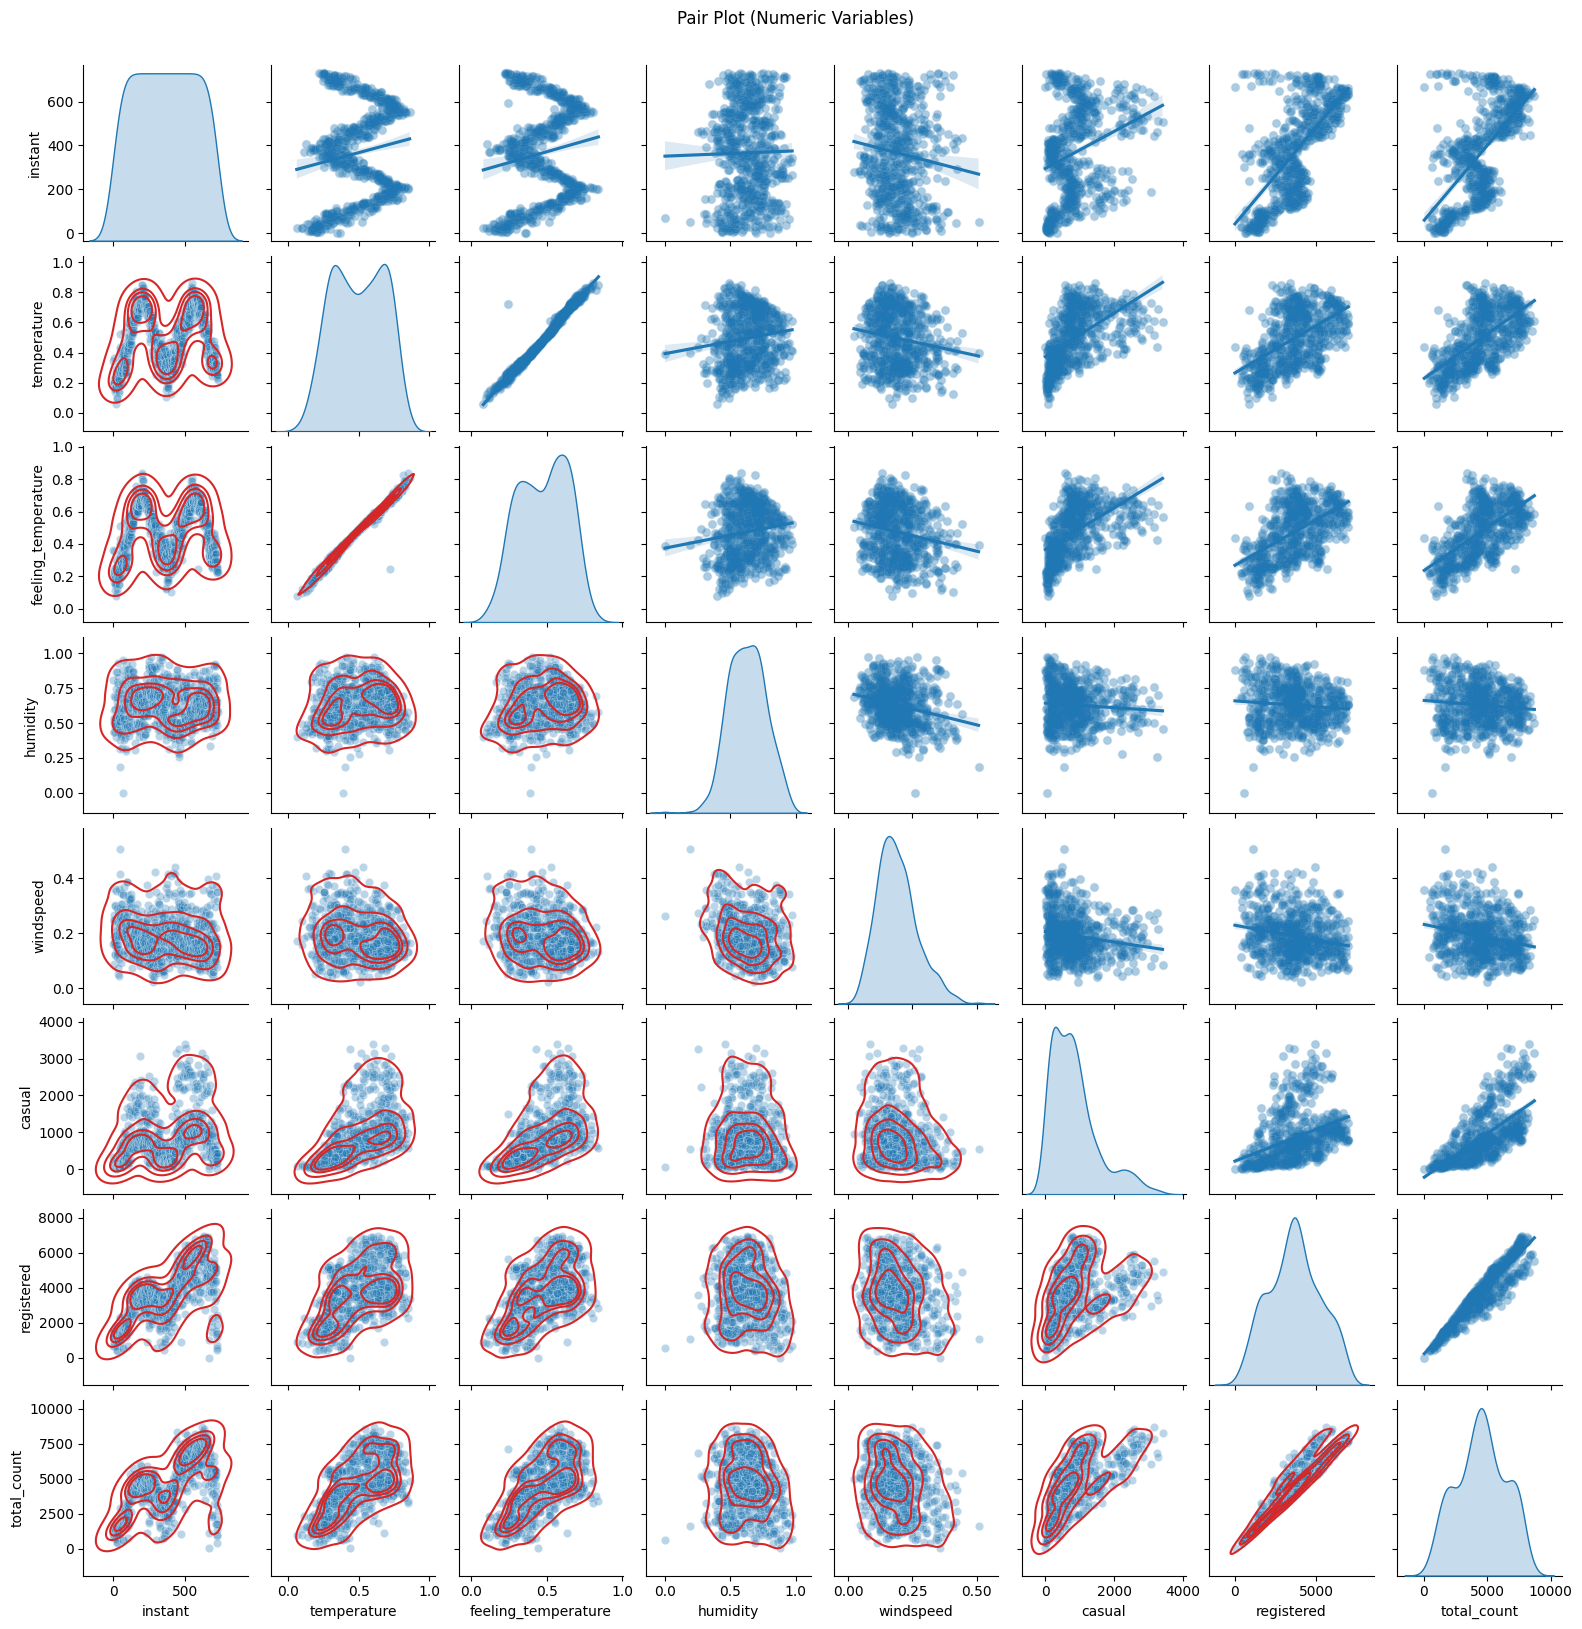

In [11]:
# optional: Palette festlegen
sns_c = sns.color_palette()

# nur die numerischen Features verwenden
data = day_bike[numerical_variables]

g = sns.pairplot(
    data=data,
    diag_kind='kde',
    height=2,
    corner=False,
    plot_kws={'alpha': 0.3}
)

# untere Dreieckszellen: KDE-Contours
g.map_lower(
    sns.kdeplot,
    levels=5,
    color=sns_c[3]
)

# obere Dreieckszellen: Regressionslinien
g.map_upper(
    sns.regplot,
    color=sns_c[0],
    scatter_kws={'alpha': 0.1}
)

# Titel anpassen
g.fig.suptitle('Pair Plot (Numeric Variables)', y=1.02)

plt.show()

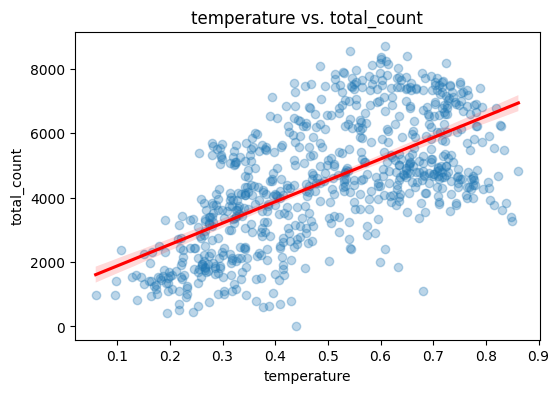

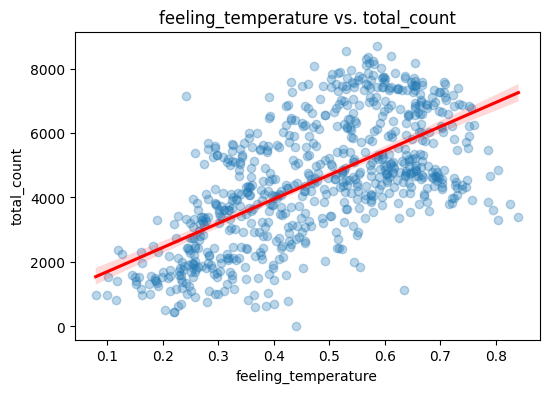

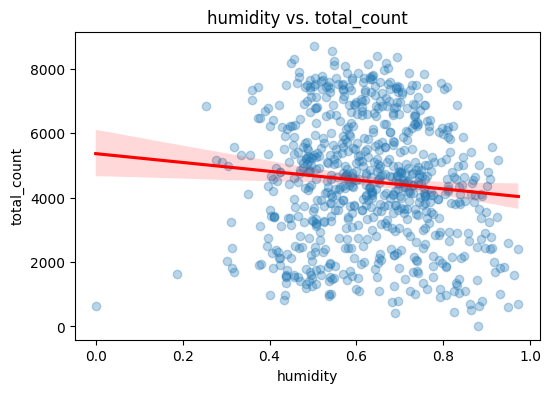

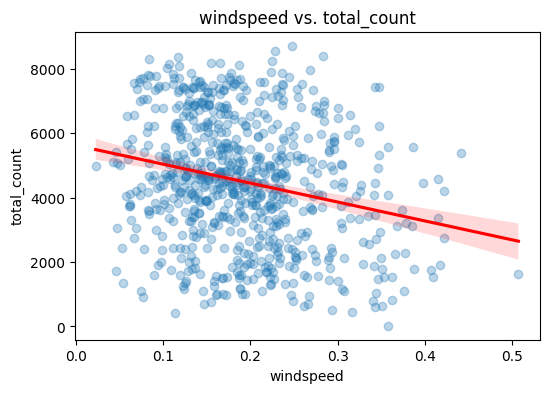

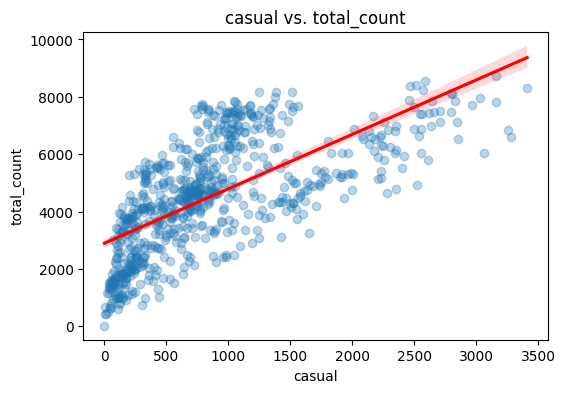

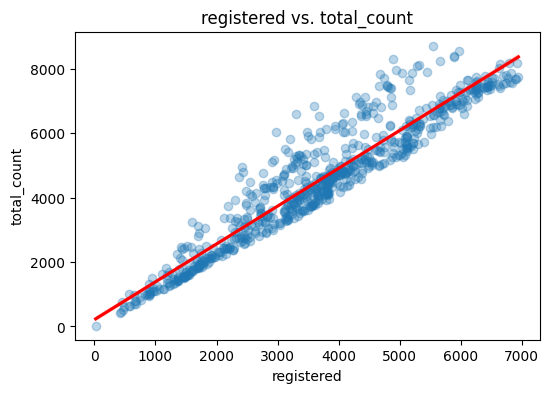

In [21]:
numeric_cols = ['temperature', 'feeling_temperature', 'humidity', 'windspeed', 'casual', 'registered']
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.regplot(x=day_bike[col], y=day_bike['total_count'], lowess=False, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
    plt.title(f'{col} vs. total_count')
    plt.show()

### Regressionsergebnis: total_count ~ temperature

                            OLS Regression Results                            
Dep. Variable:            total_count   R-squared:                       0.394
Model:                            OLS   Adj. R-squared:                  0.393
Method:                 Least Squares   F-statistic:                     473.5
Date:                 Mo, 16 Jun 2025   Prob (F-statistic):           2.81e-81
Time:                        01:10:51   Log-Likelihood:                -6386.8
No. Observations:                 731   AIC:                         1.278e+04
Df Residuals:                     729   BIC:                         1.279e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        1214.6421    161.164      7.537      

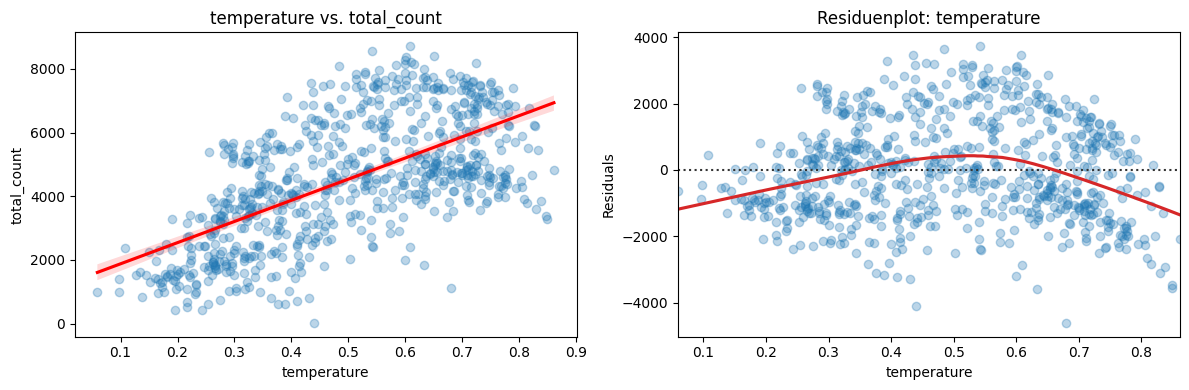

### Regressionsergebnis: total_count ~ humidity

                            OLS Regression Results                            
Dep. Variable:            total_count   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     7.462
Date:                 Mo, 16 Jun 2025   Prob (F-statistic):            0.00645
Time:                        01:10:52   Log-Likelihood:                -6566.0
No. Observations:                 731   AIC:                         1.314e+04
Df Residuals:                     729   BIC:                         1.315e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       5363.9865    322.679     16.623      0.0

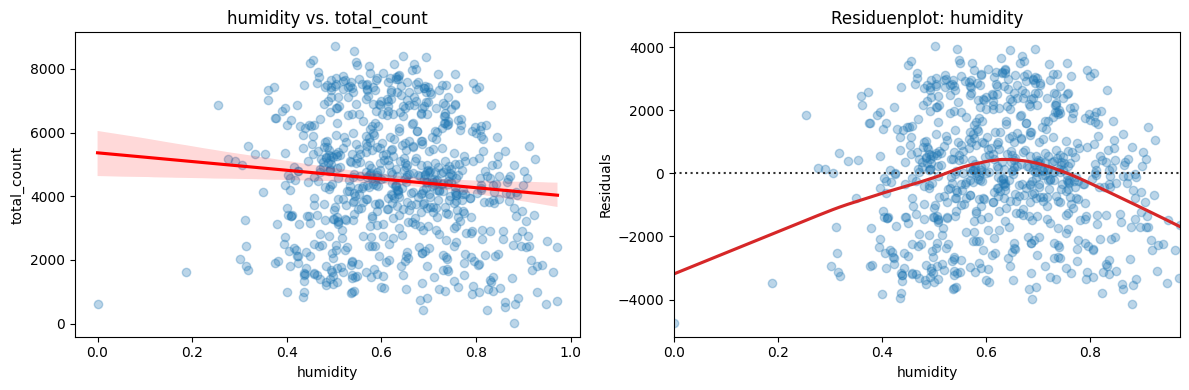

### Regressionsergebnis: total_count ~ windspeed

                            OLS Regression Results                            
Dep. Variable:            total_count   R-squared:                       0.055
Model:                            OLS   Adj. R-squared:                  0.054
Method:                 Least Squares   F-statistic:                     42.44
Date:                 Mo, 16 Jun 2025   Prob (F-statistic):           1.36e-10
Time:                        01:10:53   Log-Likelihood:                -6549.0
No. Observations:                 731   AIC:                         1.310e+04
Df Residuals:                     729   BIC:                         1.311e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       5621.1529    185.062     30.374      0.0

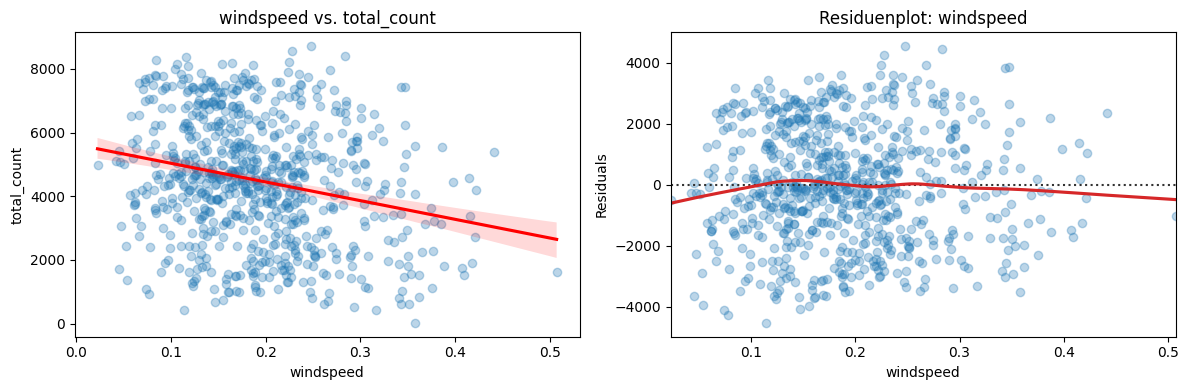

### Regressionsergebnis: total_count ~ casual

                            OLS Regression Results                            
Dep. Variable:            total_count   R-squared:                       0.453
Model:                            OLS   Adj. R-squared:                  0.452
Method:                 Least Squares   F-statistic:                     602.9
Date:                 Mo, 16 Jun 2025   Prob (F-statistic):           1.72e-97
Time:                        01:10:54   Log-Likelihood:                -6349.4
No. Observations:                 731   AIC:                         1.270e+04
Df Residuals:                     729   BIC:                         1.271e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2894.3185     84.340     34.317      0.0

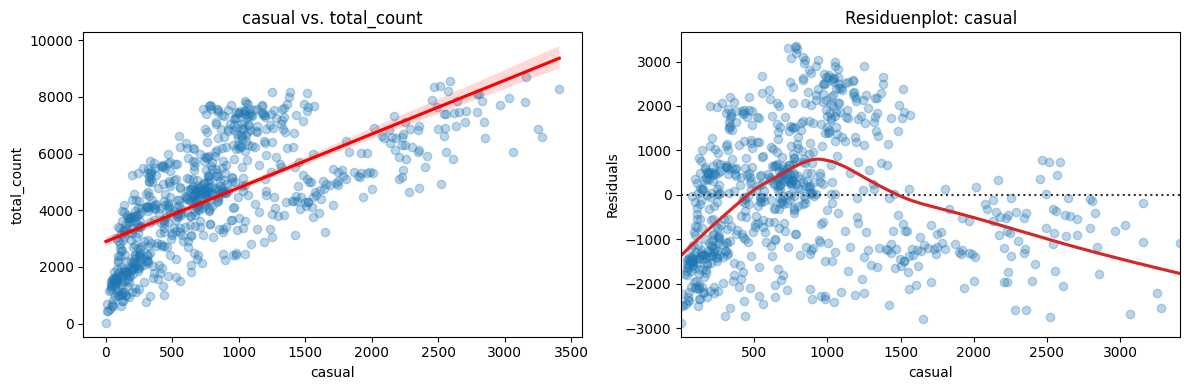

In [24]:
# Neue Zelle: Lineare Regression und Residuenplots für einzelne Features

import statsmodels.api as sm
from IPython.display import display, Markdown

features = ['temperature', 'humidity', 'windspeed', 'casual']
target = 'total_count'

for feat in features:
    # 1. Regression mit statsmodels
    X = sm.add_constant(day_bike[feat])
    model = sm.OLS(day_bike[target], X).fit()
    
    # 2. Ausgabe der Modellzusammenfassung
    display(Markdown(f"### Regressionsergebnis: {target} ~ {feat}"))
    print(model.summary())
    
    # 3. Regplot & Residualplot nebeneinander
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    sns.regplot(x=feat, y=target, data=day_bike,
                ax=axes[0], scatter_kws={'alpha': 0.3},
                line_kws={'color': 'red'})
    axes[0].set_title(f'{feat} vs. {target}')
    
    # Residualplot: Y-Achse = Residuals
    residuals = model.resid
    sns.residplot(x=day_bike[feat], y=residuals,
                  ax=axes[1], lowess=True,
                  scatter_kws={'alpha': 0.3},
                  line_kws={'color': 'C3'})
    axes[1].set_title(f'Residuenplot: {feat}')
    axes[1].set_ylabel("Residuals")
    
    plt.tight_layout()
    plt.show()

## Quadratisches Modell: total_count ~ humidity + humidity²

                            OLS Regression Results                            
Dep. Variable:            total_count   R-squared:                       0.078
Model:                            OLS   Adj. R-squared:                  0.076
Method:                 Least Squares   F-statistic:                     30.86
Date:                 Mo, 16 Jun 2025   Prob (F-statistic):           1.37e-13
Time:                        01:14:55   Log-Likelihood:                -6539.9
No. Observations:                 731   AIC:                         1.309e+04
Df Residuals:                     728   BIC:                         1.310e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1245.5145    954.185     -1.305      0.1

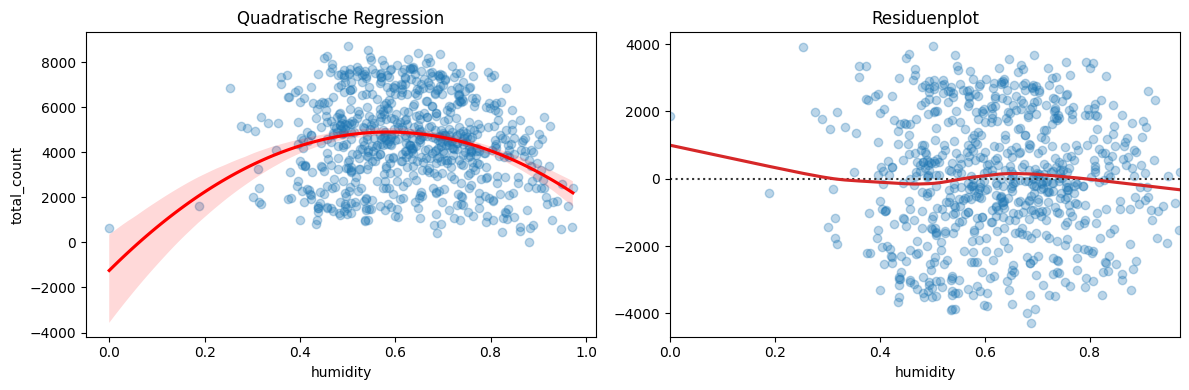

In [25]:
# Neue Zelle: Quadratisches Modell für humidity

import statsmodels.api as sm
from IPython.display import display, Markdown

# quadratischen Term einführen
day_bike['humidity2'] = day_bike['humidity']**2

X = sm.add_constant(day_bike[['humidity', 'humidity2']])
model_poly = sm.OLS(day_bike['total_count'], X).fit()

display(Markdown("## Quadratisches Modell: total_count ~ humidity + humidity²"))
print(model_poly.summary())

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.regplot(x='humidity', y='total_count', data=day_bike, order=2,
            ax=axes[0], scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
axes[0].set_title('Quadratische Regression')
sns.residplot(x='humidity', y=model_poly.resid, data=day_bike,
              ax=axes[1], lowess=True, scatter_kws={'alpha':0.3},
              line_kws={'color':'C3'})
axes[1].set_title('Residuenplot')
plt.tight_layout()
plt.show()

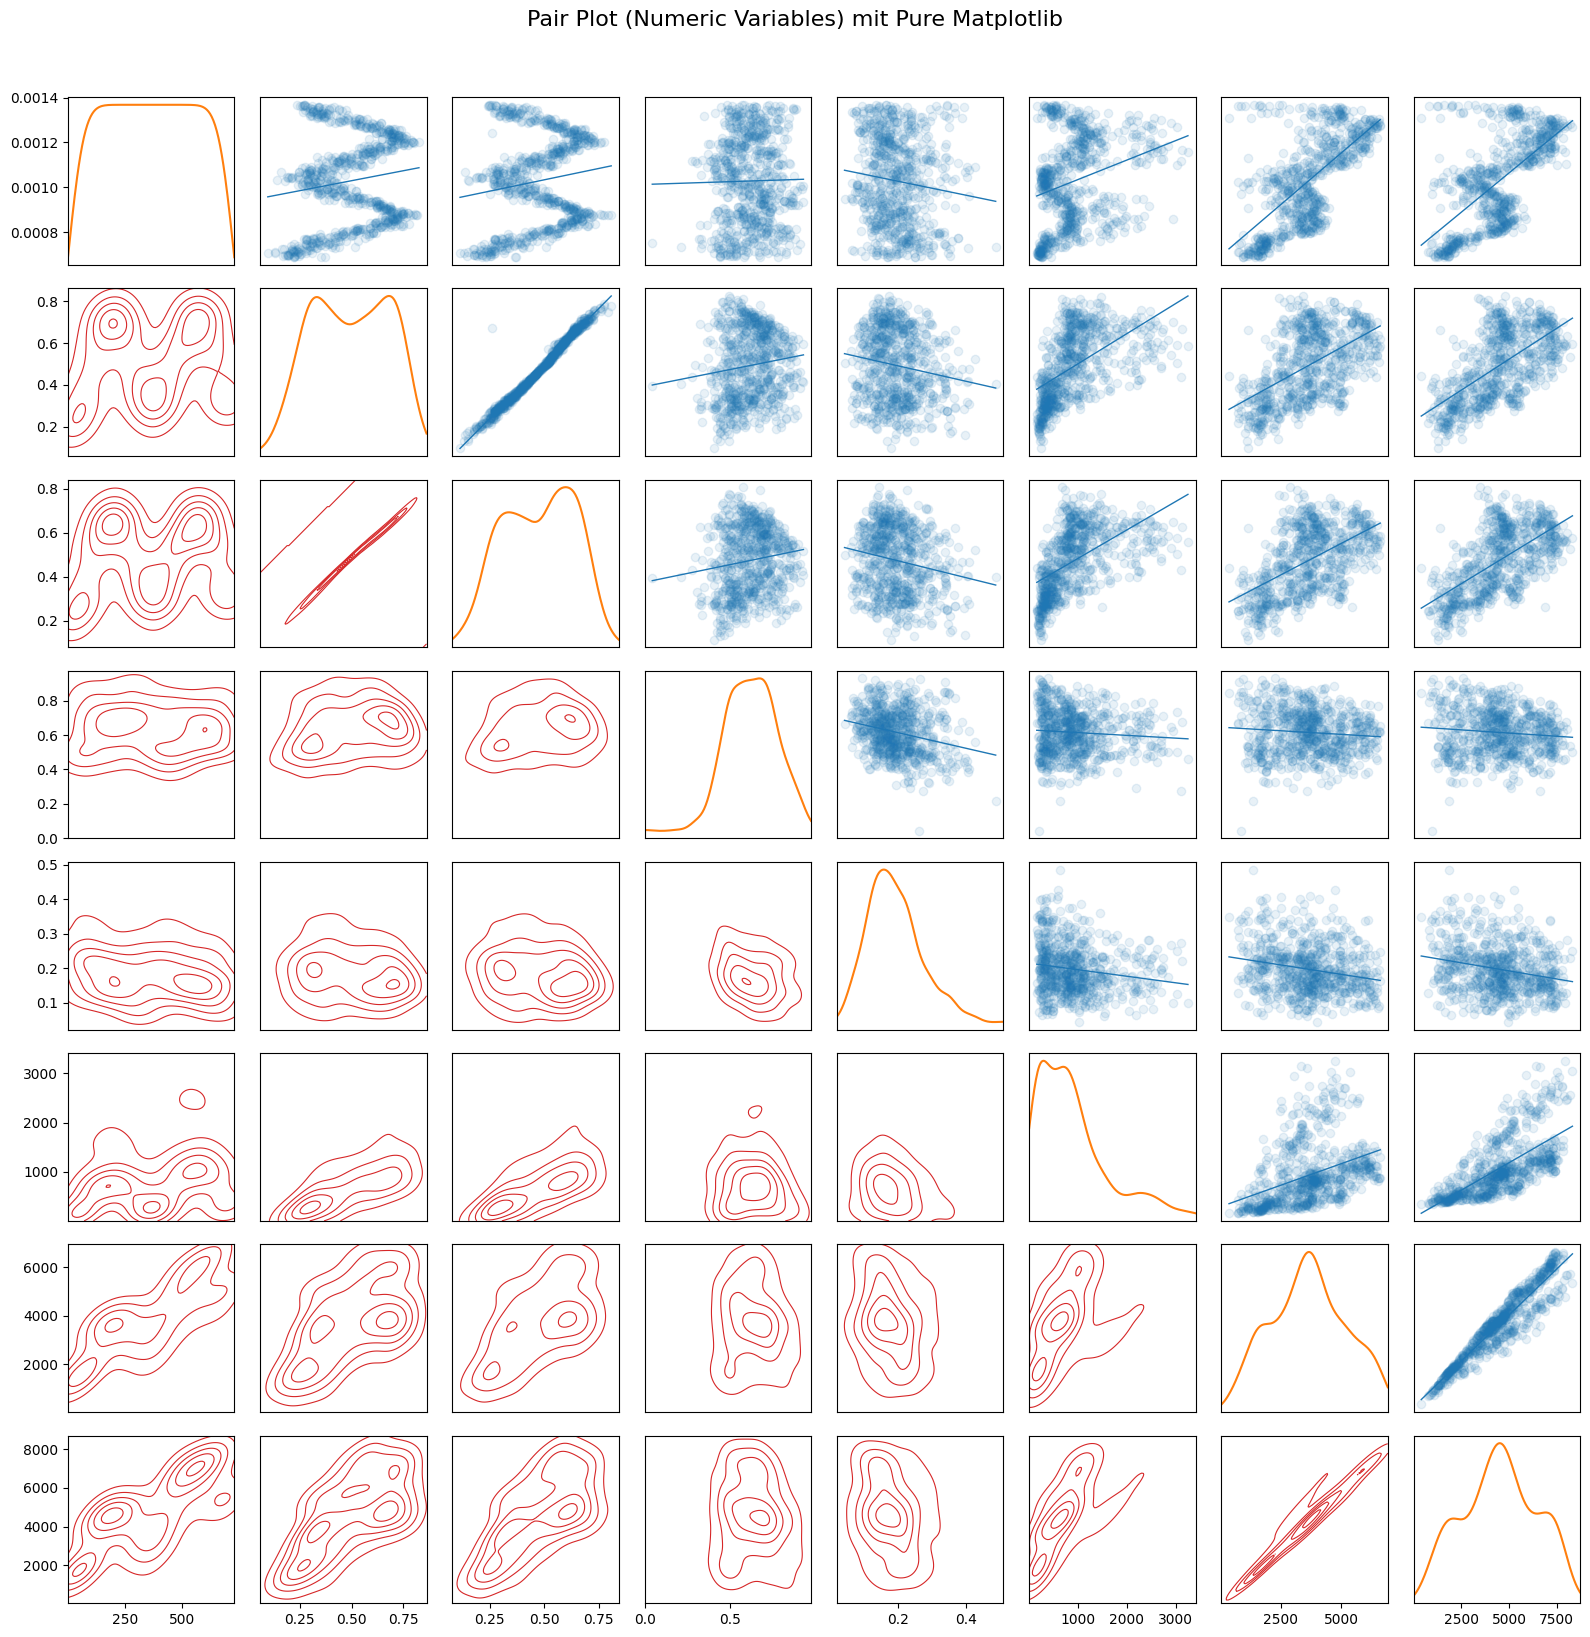

In [14]:
# Machine Learning and Data Analytics\MLDA_Project_Bike_Sharin\bike_sharing_report.ipynb
# Neue Zelle: reines matplotlib–Pairplot mit KDE-Contours und Regressionslinie

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

data = day_bike[numerical_variables]
n = len(numerical_variables)

fig, axes = plt.subplots(n, n, figsize=(2*n, 2*n))
for i, yi in enumerate(numerical_variables):
    for j, xi in enumerate(numerical_variables):
        ax = axes[i, j]
        x = data[xi].values
        y = data[yi].values

        if i == j:
            # Diagonale: univariate KDE
            kde1 = gaussian_kde(x)
            xs = np.linspace(x.min(), x.max(), 200)
            ax.plot(xs, kde1(xs), color='C1')
            ax.set_xlim(x.min(), x.max())

        elif i > j:
            # unteres Dreieck: bivariate KDE-Contours
            xy = np.vstack([x, y])
            kde2 = gaussian_kde(xy)
            xi_lin = np.linspace(x.min(), x.max(), 100)
            yi_lin = np.linspace(y.min(), y.max(), 100)
            Xg, Yg = np.meshgrid(xi_lin, yi_lin)
            Z = kde2(np.vstack([Xg.ravel(), Yg.ravel()])).reshape(Xg.shape)
            ax.contour(Xg, Yg, Z, levels=5, colors='C3', linewidths=0.8)

        else:
            # oberes Dreieck: Scatter + lineare Regression
            ax.scatter(x, y, alpha=0.1, color='C0')
            m, b = np.polyfit(x, y, 1)
            xs = np.array([x.min(), x.max()])
            ax.plot(xs, m*xs + b, color='C0', linewidth=1)

        # Achsenbeschriftungen nur außen anzeigen
        if i < n-1:
            ax.set_xticks([])
        if j > 0:
            ax.set_yticks([])

# Gesamttitel und Layout
fig.suptitle('Pair Plot (Numeric Variables) mit Pure Matplotlib', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

## Analysis of Categorical Variables

### Feature: season

season
3    188
2    184
1    181
4    178
Name: count, dtype: int64

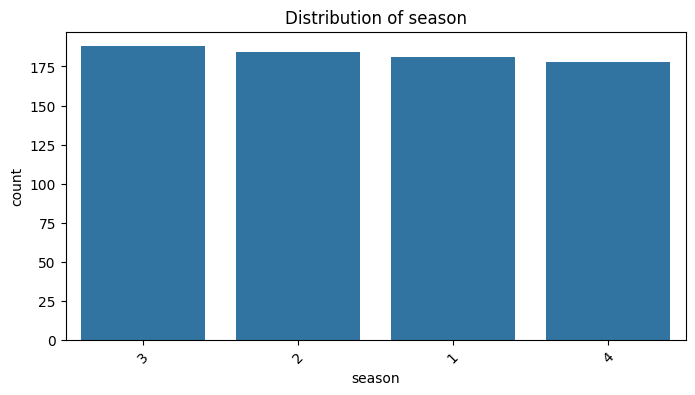

**Average total_count by season:**

season
3    5644.303191
2    4992.331522
4    4728.162921
1    2604.132597
Name: total_count, dtype: float64

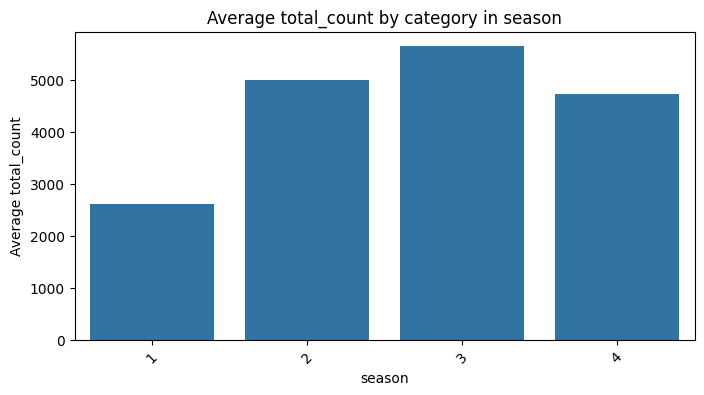

### Feature: year

year
1    366
0    365
Name: count, dtype: int64

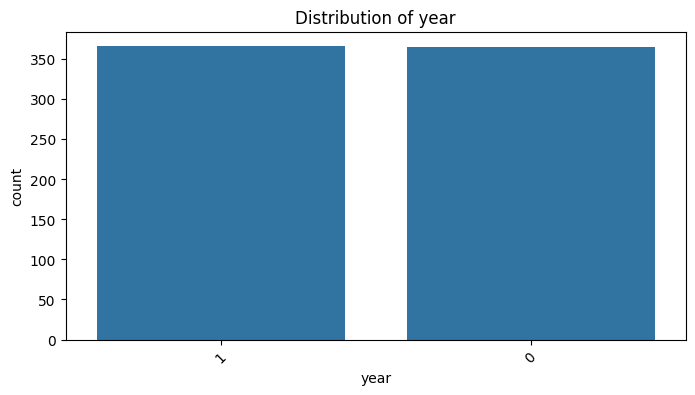

**Average total_count by year:**

year
1    5599.934426
0    3405.761644
Name: total_count, dtype: float64

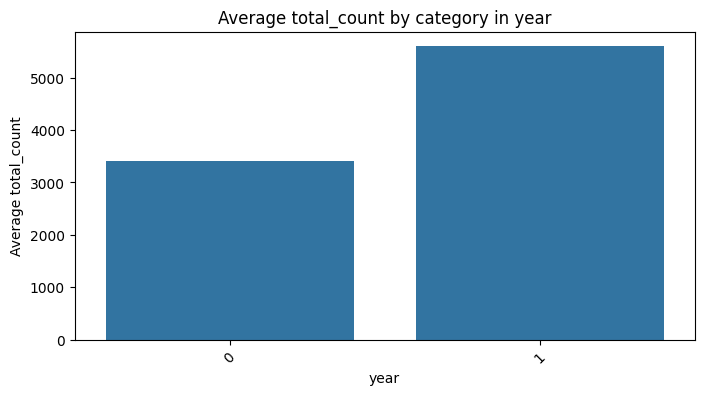

### Feature: month

month
1     62
3     62
5     62
7     62
8     62
10    62
12    62
4     60
6     60
9     60
11    60
2     57
Name: count, dtype: int64

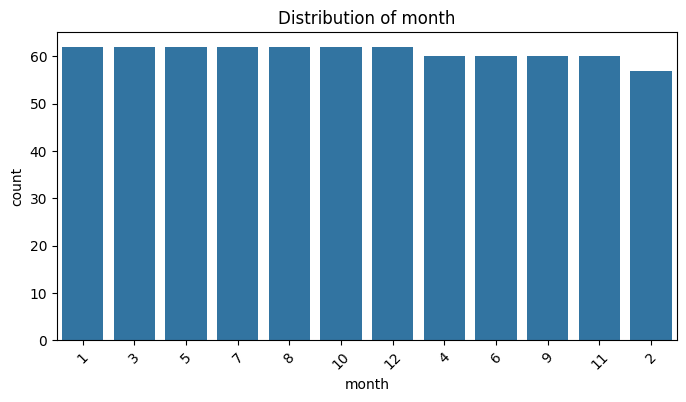

**Average total_count by month:**

month
6     5772.366667
9     5766.516667
8     5664.419355
7     5563.677419
5     5349.774194
10    5199.225806
4     4484.900000
11    4247.183333
3     3692.258065
12    3403.806452
2     2655.298246
1     2176.338710
Name: total_count, dtype: float64

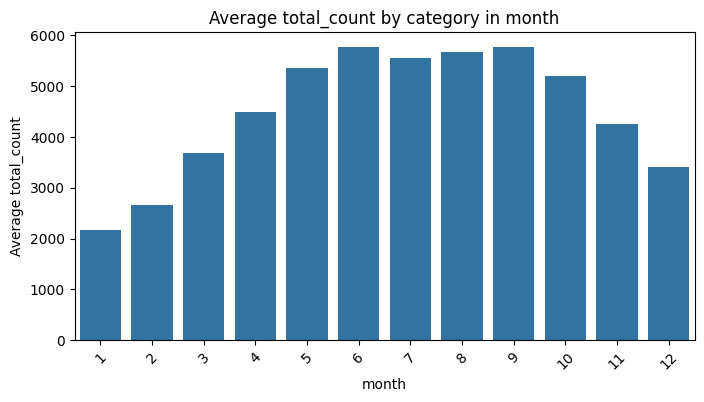

### Feature: holiday

holiday
0    710
1     21
Name: count, dtype: int64

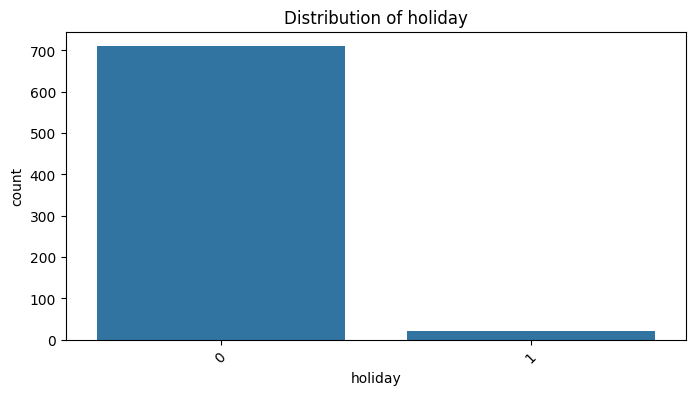

**Average total_count by holiday:**

holiday
0    4527.104225
1    3735.000000
Name: total_count, dtype: float64

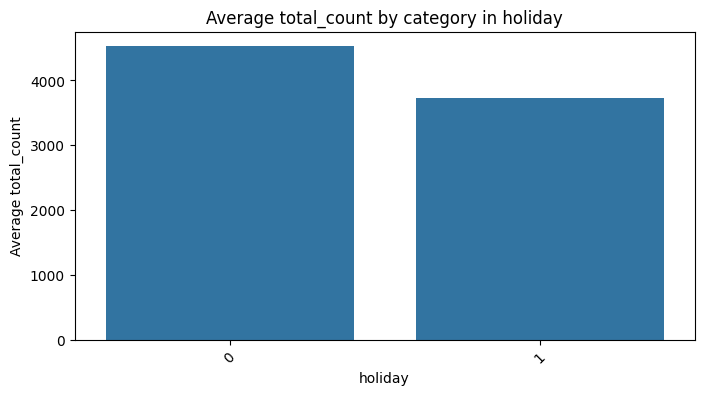

### Feature: weekday

weekday
6    105
0    105
1    105
2    104
3    104
4    104
5    104
Name: count, dtype: int64

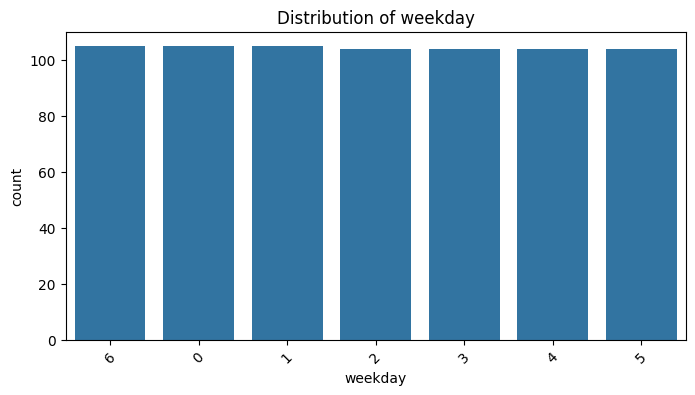

**Average total_count by weekday:**

weekday
5    4690.288462
4    4667.259615
6    4550.542857
3    4548.538462
2    4510.663462
1    4338.123810
0    4228.828571
Name: total_count, dtype: float64

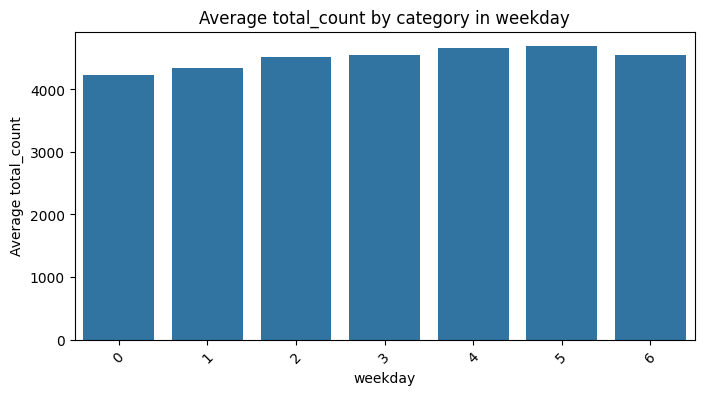

### Feature: workingday

workingday
1    500
0    231
Name: count, dtype: int64

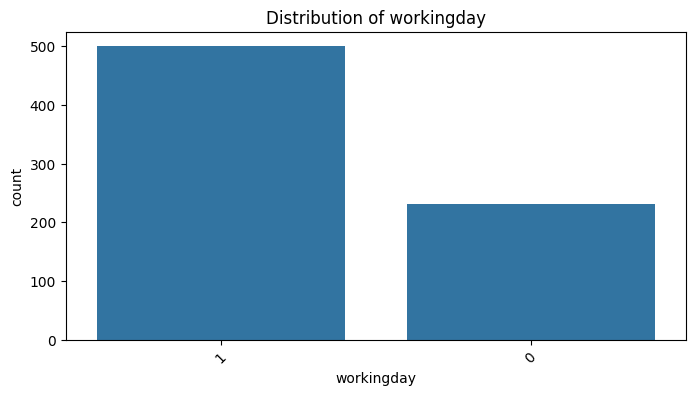

**Average total_count by workingday:**

workingday
1    4584.820000
0    4330.168831
Name: total_count, dtype: float64

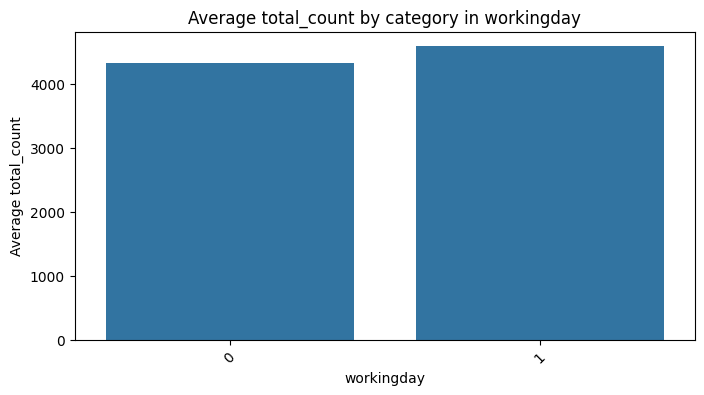

### Feature: weathersit

weathersit
1    463
2    247
3     21
Name: count, dtype: int64

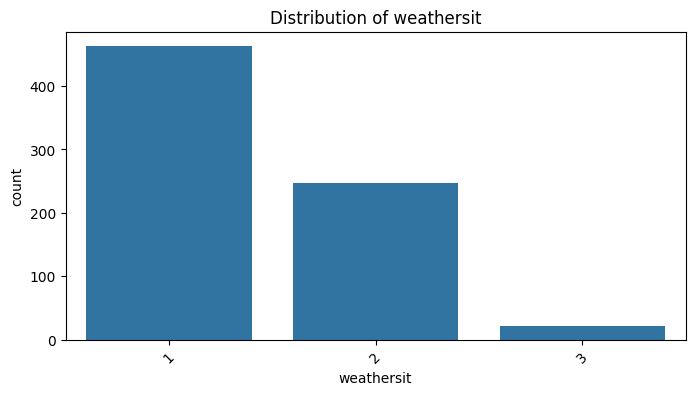

**Average total_count by weathersit:**

weathersit
1    4876.786177
2    4035.862348
3    1803.285714
Name: total_count, dtype: float64

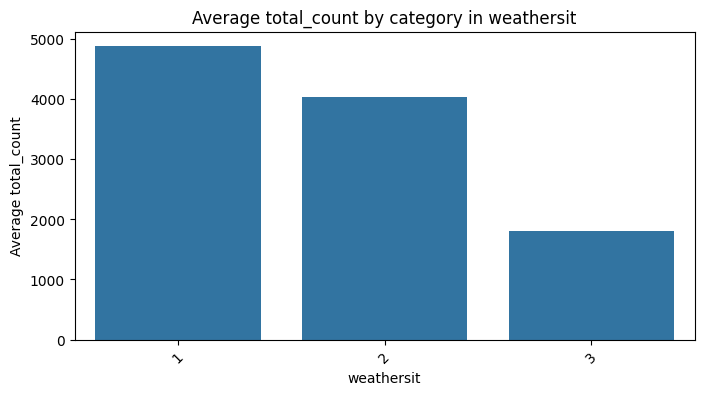

In [12]:
# New Cell: Analysis of Categorical Variables
from IPython.display import display, Markdown

def analyze_categorical_features(df, cat_features, target=None):
    """
    Analyzes categorical variables:
    - Displays frequency distributions
    - Plots countplots for each feature
    - (Optional) Aggregates by feature and calculates the mean of the target variable
    """
    display(Markdown("## Analysis of Categorical Variables"))
    
    for feature in cat_features:
        display(Markdown(f"### Feature: {feature}"))
        
        # Display the frequency distribution
        counts = df[feature].value_counts()
        display(counts)
        
        # Create a countplot
        plt.figure(figsize=(8, 4))
        sns.countplot(x=feature, data=df, order=counts.index)
        plt.title(f'Distribution of {feature}')
        plt.xticks(rotation=45)
        plt.show()
        
        # Optional analysis: aggregate target variable if provided
        if target is not None and target in df.columns:
            group_stats = df.groupby(feature)[target].mean().sort_values(ascending=False)
            display(Markdown(f"**Average {target} by {feature}:**"))
            display(group_stats)
            plt.figure(figsize=(8, 4))
            sns.barplot(x=group_stats.index, y=group_stats.values)
            plt.title(f'Average {target} by category in {feature}')
            plt.xticks(rotation=45)
            plt.ylabel(f'Average {target}')
            plt.show()

# Calling the function with your categorical variables
analyze_categorical_features(day_bike, categorical_variables, target="total_count")

## Analysis of Categorical Variables

### Feature: season

season
3    188
2    184
1    181
4    178
Name: count, dtype: int64

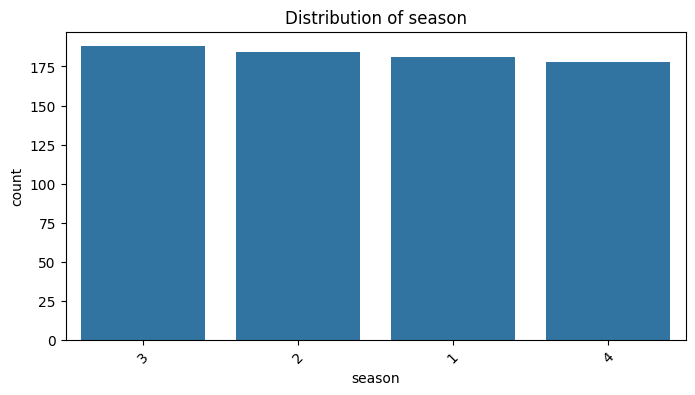

**Average total_count by season:**

season
3    5644.303191
2    4992.331522
4    4728.162921
1    2604.132597
Name: total_count, dtype: float64

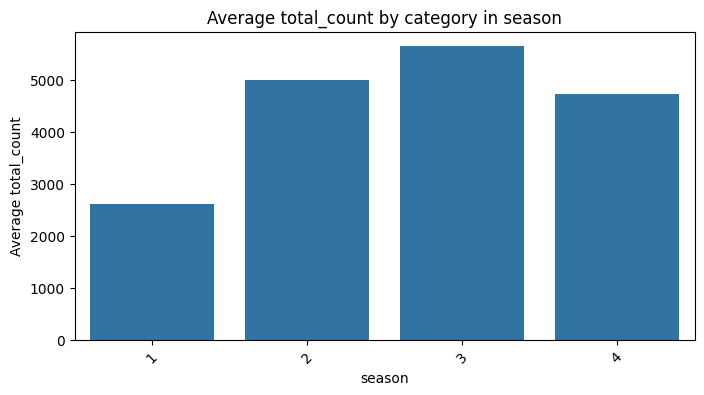

### Feature: year

year
1    366
0    365
Name: count, dtype: int64

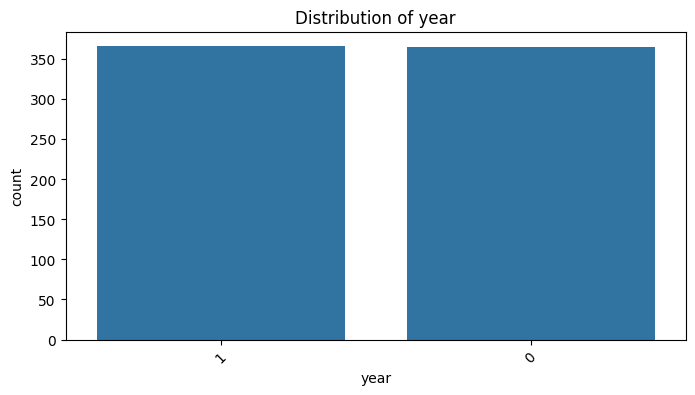

**Average total_count by year:**

year
1    5599.934426
0    3405.761644
Name: total_count, dtype: float64

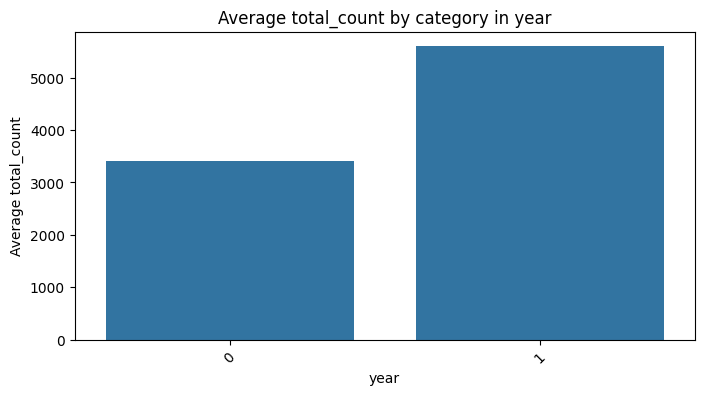

### Feature: month

month
1     62
3     62
5     62
7     62
8     62
10    62
12    62
4     60
6     60
9     60
11    60
2     57
Name: count, dtype: int64

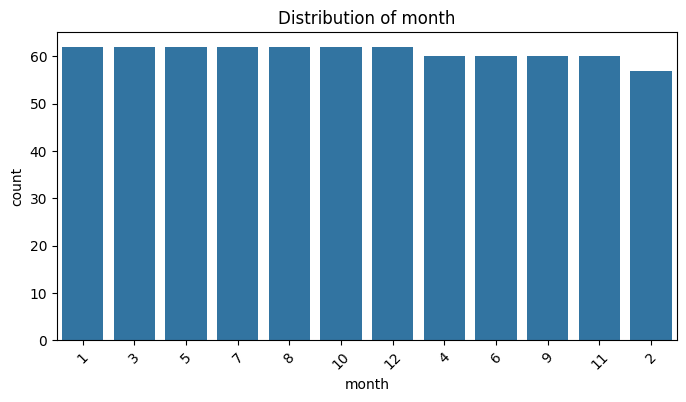

**Average total_count by month:**

month
6     5772.366667
9     5766.516667
8     5664.419355
7     5563.677419
5     5349.774194
10    5199.225806
4     4484.900000
11    4247.183333
3     3692.258065
12    3403.806452
2     2655.298246
1     2176.338710
Name: total_count, dtype: float64

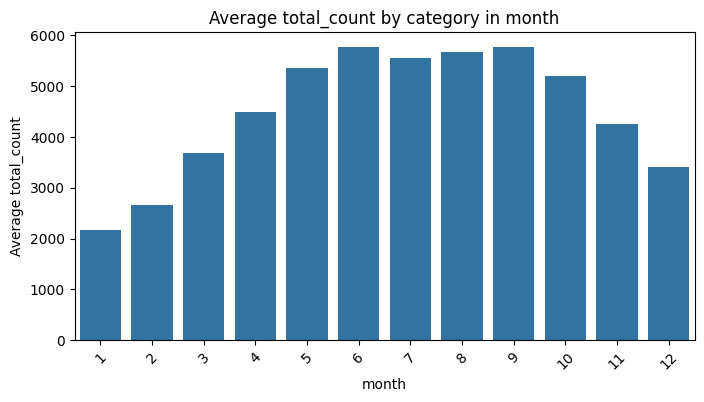

### Feature: holiday

holiday
0    710
1     21
Name: count, dtype: int64

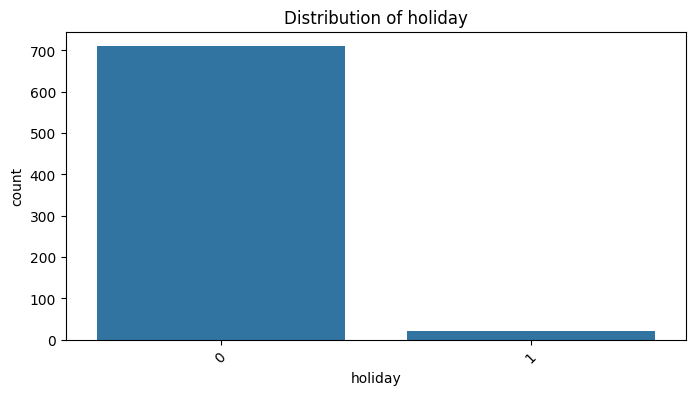

**Average total_count by holiday:**

holiday
0    4527.104225
1    3735.000000
Name: total_count, dtype: float64

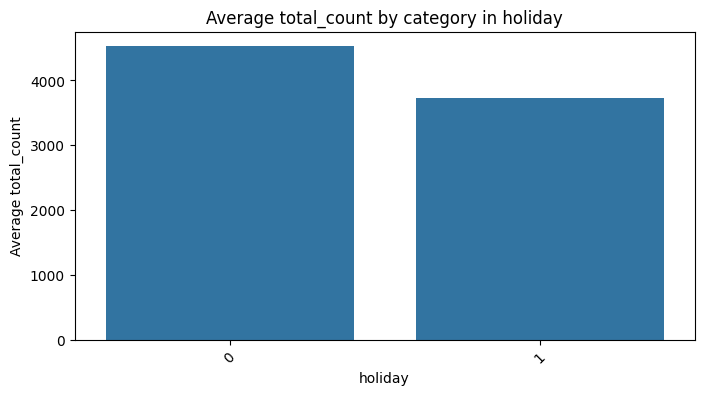

### Feature: weekday

weekday
6    105
0    105
1    105
2    104
3    104
4    104
5    104
Name: count, dtype: int64

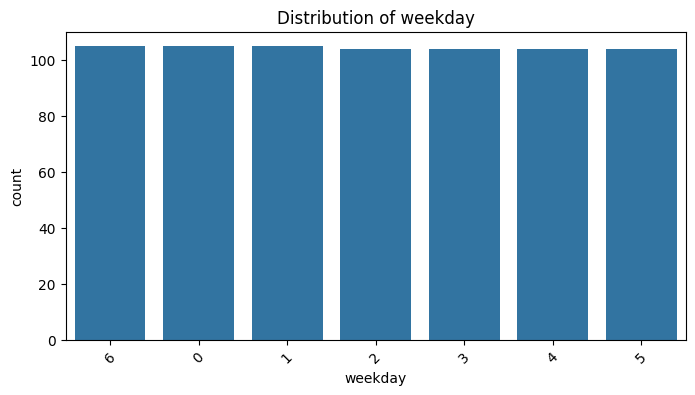

**Average total_count by weekday:**

weekday
5    4690.288462
4    4667.259615
6    4550.542857
3    4548.538462
2    4510.663462
1    4338.123810
0    4228.828571
Name: total_count, dtype: float64

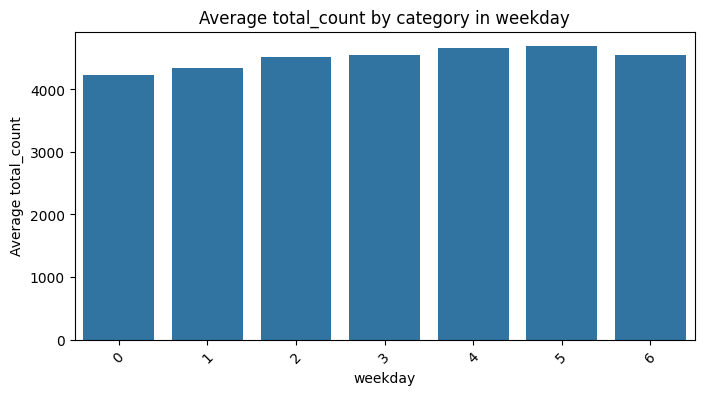

### Feature: workingday

workingday
1    500
0    231
Name: count, dtype: int64

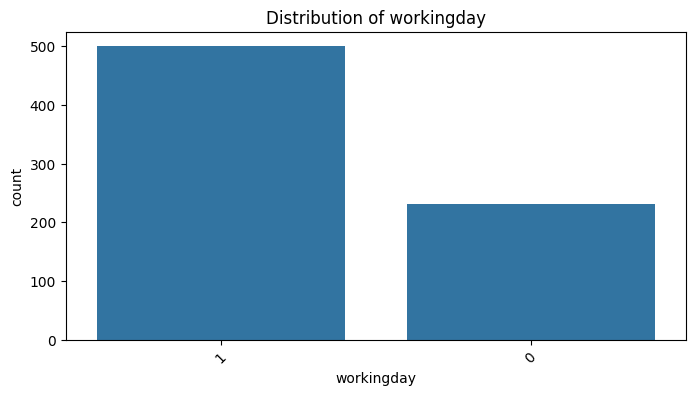

**Average total_count by workingday:**

workingday
1    4584.820000
0    4330.168831
Name: total_count, dtype: float64

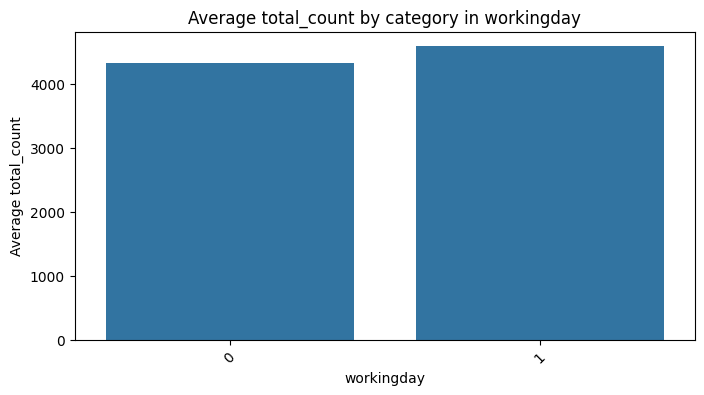

### Feature: weathersit

weathersit
1    463
2    247
3     21
Name: count, dtype: int64

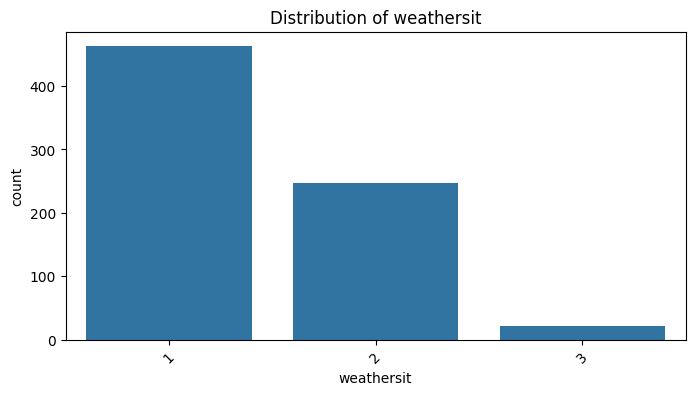

**Average total_count by weathersit:**

weathersit
1    4876.786177
2    4035.862348
3    1803.285714
Name: total_count, dtype: float64

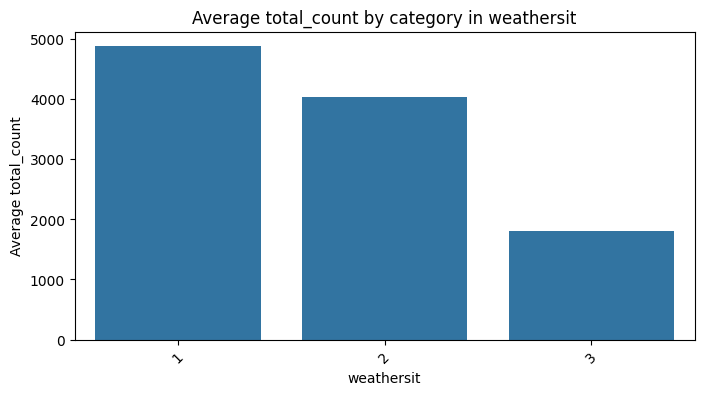

In [13]:
# New Cell: Analysis of Categorical Variables
from IPython.display import display, Markdown

def analyze_categorical_features(df, cat_features, target=None):
    """
    Analyzes categorical variables:
    - Displays frequency distributions
    - Plots countplots for each feature
    - (Optional) Aggregates by feature and calculates the mean of the target variable
    """
    display(Markdown("## Analysis of Categorical Variables"))
    
    for feature in cat_features:
        display(Markdown(f"### Feature: {feature}"))
        
        # Display the frequency distribution
        counts = df[feature].value_counts()
        display(counts)
        
        # Create a countplot
        plt.figure(figsize=(8, 4))
        sns.countplot(x=feature, data=df, order=counts.index)
        plt.title(f'Distribution of {feature}')
        plt.xticks(rotation=45)
        plt.show()
        
        # Optional analysis: aggregate target variable if provided
        if target is not None and target in df.columns:
            group_stats = df.groupby(feature)[target].mean().sort_values(ascending=False)
            display(Markdown(f"**Average {target} by {feature}:**"))
            display(group_stats)
            plt.figure(figsize=(8, 4))
            sns.barplot(x=group_stats.index, y=group_stats.values)
            plt.title(f'Average {target} by category in {feature}')
            plt.xticks(rotation=45)
            plt.ylabel(f'Average {target}')
            plt.show()

# Calling the function with your categorical variables
analyze_categorical_features(day_bike, categorical_variables, target="total_count")

# 3. Modeling  

# 4. Model Evaluation  

# 5 Conclusion and Future Outlook